In [17]:
from pathlib import Path

In [18]:
ROOT_PATH = Path.cwd()
DATA_BASE_PATH = ROOT_PATH / "data"
GPS_TRACKS_PATH = DATA_BASE_PATH / "gps_track.txt"
GROUND_TRUTH_PATH = DATA_BASE_PATH / "groundtruth.txt"
GRAPH_PATH = DATA_BASE_PATH / "melbourne_reconstructed.graphml"

In [19]:
from datetime import datetime
from mmlib.types import GPSPoint


def load_gps_tracks(file_path: Path) -> list[GPSPoint]:
    gps_points = []
    with open(file_path, "r") as f:
        next(f)
        for line in f:
            unix_ts, lat, lon = map(float, line.strip().split())
            unix_ts = float(unix_ts)
            gps_points.append(
                GPSPoint(lat=lat, lon=lon, time=datetime.fromtimestamp(unix_ts))
            )
    return gps_points

In [20]:
def load_gt_edge_ids(file_path: Path) -> list[str]:
    gt_edge_ids = []
    with open(file_path, "r") as f:
        next(f)
        for line in f:
            edge_id = line.strip()
            gt_edge_ids.append(edge_id)
    return gt_edge_ids

In [21]:
gt_ids = load_gt_edge_ids(DATA_BASE_PATH / "groundtruth.txt")
gt_ids[:5]

['125157', '125158', '173643', '173644', '173645']

In [22]:
gps_points = load_gps_tracks(GPS_TRACKS_PATH)
gps_points[:5]

[GPSPoint(lat=-37.798779, lon=144.947925, time=datetime.datetime(2013, 10, 12, 15, 15, 22)),
 GPSPoint(lat=-37.798775, lon=144.9479, time=datetime.datetime(2013, 10, 12, 15, 15, 23)),
 GPSPoint(lat=-37.798749, lon=144.947885, time=datetime.datetime(2013, 10, 12, 15, 15, 24)),
 GPSPoint(lat=-37.798734, lon=144.947865, time=datetime.datetime(2013, 10, 12, 15, 15, 25)),
 GPSPoint(lat=-37.798723, lon=144.947869, time=datetime.datetime(2013, 10, 12, 15, 15, 26))]

In [23]:
from mmlib.matcher.offline import osrm_matcher

matcher = osrm_matcher("http://localhost:5000")
result = matcher.match(gps_points)
result.plot(zoom=12)

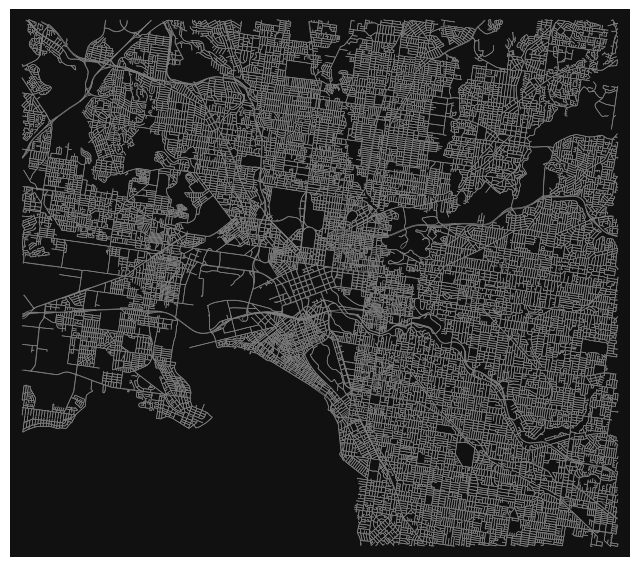

/tmp/ipykernel_50269/916161387.py:4: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



In [26]:
import osmnx as ox

G = ox.load_graphml(GRAPH_PATH)
fig, ax = ox.plot_graph(G, node_size=0, edge_color="gray", edge_linewidth=0.5)
fig.show()

In [28]:
result.plot_on_folium(G, gt_ids).show_in_browser()

Your map should have been opened in your browser automatically.
Press ctrl+c to return.


kf.service.services: KApplicationTrader: mimeType "x-scheme-handler/file" not found
Fontconfig error: Cannot load default config file: File not found
